In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [2]:
df = pd.read_csv('GLP1_CLEANED.csv')

print("=== Post-Cleaning Validation ===")
print(f"Shape:         {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Nulls:         {df.isnull().sum().sum()}")
print(f"Columns:       {list(df.columns)}")
print(f"\nNumeric summary:")
numeric_features = ['RIDAGEYR', 'BMXBMI', 'LBXGH', 'avg_oop_cost',
                    'income_cost_pressure', 'bio_friction', 'system_refill_score']
df[numeric_features].describe().T[['mean','std','min','50%','max']].rename(columns={'50%':'median'})


=== Post-Cleaning Validation ===
Shape:         7,566 rows × 15 columns
Nulls:         0
Columns:       ['RIDAGEYR', 'gender_female', 'BMXBMI', 'LBXGH', 'assigned_molecule', 'drug_generation', 'is_newer_drug', 'avg_oop_cost', 'income_cost_pressure', 'bio_friction', 'system_refill_score', 'comorbidity_score', 'has_dyslipidemia', 'has_dysglycemia', 'is_adherent']

Numeric summary:


,mean,std,min,median,max
RIDAGEYR,54.3199,16.9610,18.0000,58.0000,80.0000
BMXBMI,34.6368,6.8255,18.5000,33.3000,70.0000
LBXGH,6.1997,1.3450,3.9000,5.8000,17.1000
avg_oop_cost,56.8729,46.0492,2.1700,49.1500,424.1900
income_cost_pressure,33.7902,48.1115,0.4255,19.9157,366.7414
bio_friction,0.4642,0.1518,0.2369,0.5657,0.5657
system_refill_score,1.1213,0.1168,0.9216,1.1383,1.3387


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("=== Preprocessing ===")
print(f"Unique molecules before encoding: {df['assigned_molecule'].unique()}")

df_model = pd.get_dummies(df, columns=['assigned_molecule'], prefix='mol', dtype=int)

new_mol_cols = [c for c in df_model.columns if c.startswith('mol_')]
print(f"\n✅ One-hot encoded into: {new_mol_cols}")
print(f"New shape: {df_model.shape}")

=== Preprocessing ===
Unique molecules before encoding: ['SEMAGLUTIDE' 'LIRAGLUTIDE' 'DULAGLUTIDE' 'TIRZEPATIDE']

✅ One-hot encoded into: ['mol_DULAGLUTIDE', 'mol_LIRAGLUTIDE', 'mol_SEMAGLUTIDE', 'mol_TIRZEPATIDE']
New shape: (7566, 18)


In [4]:
TARGET = 'is_adherent'

# Exclude target — everything else is a feature
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Features ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  {f}")
print(f"\nTarget: {TARGET}")
print(f"X shape: {X.shape} | y shape: {y.shape}")

Features (17):
  RIDAGEYR
  gender_female
  BMXBMI
  LBXGH
  drug_generation
  is_newer_drug
  avg_oop_cost
  income_cost_pressure
  bio_friction
  system_refill_score
  comorbidity_score
  has_dyslipidemia
  has_dysglycemia
  mol_DULAGLUTIDE
  mol_LIRAGLUTIDE
  mol_SEMAGLUTIDE
  mol_TIRZEPATIDE

Target: is_adherent
X shape: (7566, 17) | y shape: (7566,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y       # preserves the 47/53 ratio in both splits
)

print("=== Train / Test Split ===")
print(f"Training set:  {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:      {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass balance in training set:")
print(f"  Adherent (1): {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.1f}%)")
print(f"  Dropout  (0): {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.1f}%)")
print(f"\nClass balance in test set:")
print(f"  Adherent (1): {(y_test==1).sum():,}  ({(y_test==1).mean()*100:.1f}%)")
print(f"  Dropout  (0): {(y_test==0).sum():,}  ({(y_test==0).mean()*100:.1f}%)")

=== Train / Test Split ===
Training set:  6,052 rows (80%)
Test set:      1,514 rows (20%)

Class balance in training set:
  Adherent (1): 2,844  (47.0%)
  Dropout  (0): 3,208  (53.0%)

Class balance in test set:
  Adherent (1): 712  (47.0%)
  Dropout  (0): 802  (53.0%)


In [6]:
# Only scale continuous features — leave binaries and one-hot cols alone
SCALE_COLS = ['RIDAGEYR', 'BMXBMI', 'LBXGH', 'avg_oop_cost',
              'income_cost_pressure', 'bio_friction', 'system_refill_score']

scaler = StandardScaler()

X_train = X_train.copy()
X_test  = X_test.copy()

# Fit ONLY on training data — transform both
X_train[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])

print("=== Feature Scaling ===")
print(f"✅ StandardScaler fitted on training set only")
print(f"✅ Applied to test set using training parameters")
print(f"\nPost-scale means (training, should be ~0):")
for col in SCALE_COLS:
    print(f"  {col:<25} mean={X_train[col].mean():.4f}  std={X_train[col].std():.4f}")

=== Feature Scaling ===
✅ StandardScaler fitted on training set only
✅ Applied to test set using training parameters

Post-scale means (training, should be ~0):
  RIDAGEYR                  mean=-0.0000  std=1.0001
  BMXBMI                    mean=-0.0000  std=1.0001
  LBXGH                     mean=0.0000  std=1.0001
  avg_oop_cost              mean=0.0000  std=1.0001
  income_cost_pressure      mean=-0.0000  std=1.0001
  bio_friction              mean=-0.0000  std=1.0001
  system_refill_score       mean=-0.0000  std=1.0001


In [7]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import time

print("=== Model Training ===\n")

# --- Gradient Boosting (primary) ---
print("Training Gradient Boosting Classifier...")
t0 = time.time()
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)
print(f"  ✅ Done in {time.time()-t0:.1f}s")

# --- Logistic Regression (baseline) ---
print("\nTraining Logistic Regression (baseline)...")
t0 = time.time()
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0
)
lr_model.fit(X_train, y_train)
print(f"  ✅ Done in {time.time()-t0:.1f}s")

print("\n✅ Both models trained successfully")

=== Model Training ===

Training Gradient Boosting Classifier...
  ✅ Done in 2.8s

Training Logistic Regression (baseline)...
  ✅ Done in 0.0s

✅ Both models trained successfully


In [8]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)

def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy:   {acc:.4f}  {'✅' if acc >= 0.75 else '⚠️  below 0.75 target'}")
    print(f"  Precision:  {prec:.4f}")
    print(f"  Recall:     {rec:.4f}")
    print(f"  F1 Score:   {f1:.4f}")
    print(f"  AUC-ROC:    {auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['Dropout (0)', 'Adherent (1)'],
                                ))
    return {'accuracy': acc, 'precision': prec, 'recall': rec,
            'f1': f1, 'auc': auc, 'y_pred': y_pred, 'y_proba': y_proba}

gb_results = evaluate_model("Gradient Boosting (Primary)",  gb_model, X_test, y_test)
lr_results = evaluate_model("Logistic Regression (Baseline)", lr_model, X_test, y_test)


  Gradient Boosting (Primary)
  Accuracy:   0.7985  ✅
  Precision:  0.8776
  Recall:     0.6643
  F1 Score:   0.7562
  AUC-ROC:    0.8906

  Classification Report:
              precision    recall  f1-score   support

 Dropout (0)       0.75      0.92      0.83       802
Adherent (1)       0.88      0.66      0.76       712

    accuracy                           0.80      1514
   macro avg       0.82      0.79      0.79      1514
weighted avg       0.81      0.80      0.79      1514


  Logistic Regression (Baseline)
  Accuracy:   0.7635  ✅
  Precision:  0.8352
  Recall:     0.6194
  F1 Score:   0.7113
  AUC-ROC:    0.8386

  Classification Report:
              precision    recall  f1-score   support

 Dropout (0)       0.73      0.89      0.80       802
Adherent (1)       0.84      0.62      0.71       712

    accuracy                           0.76      1514
   macro avg       0.78      0.76      0.76      1514
weighted avg       0.78      0.76      0.76      1514



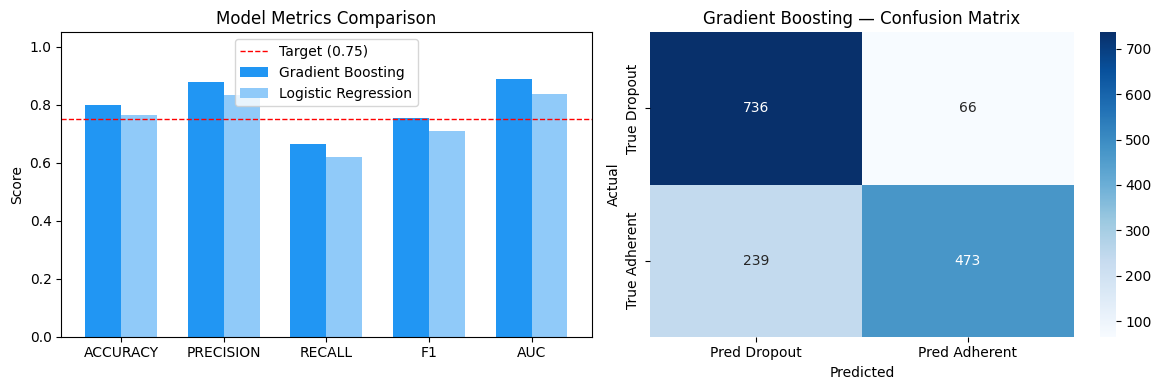

✅ Saved model_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models     = ['Gradient Boosting', 'Logistic Regression']
results    = [gb_results, lr_results]
metrics    = ['accuracy', 'precision', 'recall', 'f1', 'auc']

# Metric comparison bar chart
x = np.arange(len(metrics))
width = 0.35
axes[0].bar(x - width/2, [gb_results[m] for m in metrics], width, label='Gradient Boosting', color='#2196F3')
axes[0].bar(x + width/2, [lr_results[m] for m in metrics], width, label='Logistic Regression', color='#90CAF9')
axes[0].axhline(0.75, color='red', linestyle='--', linewidth=1, label='Target (0.75)')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.upper() for m in metrics])
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Model Metrics Comparison')
axes[0].legend()
axes[0].set_ylabel('Score')

# Confusion matrix for best model (GB)
cm = confusion_matrix(y_test, gb_results['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1], cmap='Blues',
            xticklabels=['Pred Dropout', 'Pred Adherent'],
            yticklabels=['True Dropout', 'True Adherent'])
axes[1].set_title('Gradient Boosting — Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved model_comparison.png")

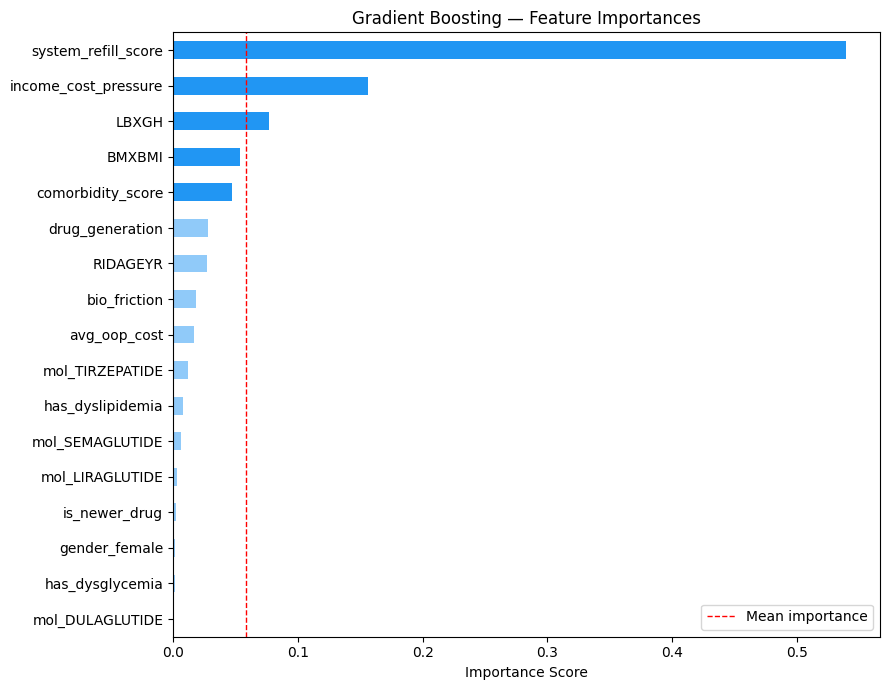

✅ Saved feature_importance.png


In [10]:
importances = pd.Series(gb_model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 7))
colors = ['#2196F3' if v >= importances.quantile(0.75) else '#90CAF9' for v in importances]
importances.plot(kind='barh', color=colors)
plt.axvline(importances.mean(), color='red', linestyle='--', linewidth=1, label='Mean importance')
plt.title('Gradient Boosting — Feature Importances')
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved feature_importance.png")